CIFAR-10 Image Classification :
The CIFAR-10 dataset is a collection of 60k images of 32x32 pixel and RGB Channel in 10 different classses.



In [ ]:
#Import the required Torch packages
import torch
import torchvision
import torchvision.transforms as transforms
IMG_SIZE=32
train_transform=transforms.Compose( [
  #transforms.Compose -> This simply chains multiple transformations together
  transforms.Resize((IMG_SIZE, IMG_SIZE)),
  transforms.RandomHorizontalFlip(p=0.5),
  transforms.RandomRotation(degrees=15),
  transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
  transforms.ToTensor(),                                              # First: Convert Image -> Tensor, does 2 things : vonverts images to pytorch tensors and scales pixel values from[0,255] ->[0,1]
  transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])]     # Second: Normalize the Tensor , normalizes each color channel (R, G, B). Final range becomes [-1,1]
)
eval_transform=transforms.Compose(
                                  #
  #transforms.Compose -> This simply chains multiple transformations together
    [transforms.ToTensor(),                                   # First: Convert Image -> Tensor, does 2 things : vonverts images to pytorch tensors and scales pixel values from[0,255] ->[0,1]
     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])]     # Second: Normalize the Tensor , normalizes each color channel (R, G, B). Final range becomes [-1,1]
)
# Why do we normalize?
# To center data around 0,Helps neural networks train faster,Improves numerical stability

testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=eval_transform)
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=train_transform)

classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

In [ ]:
# We will feed our data in batches , so we need to generate train and test loaders
batch_size=64
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True,pin_memory=True,num_workers=2)
testloader=torch.utils.data.DataLoader(testset,batch_size=batch_size,shuffle=False,num_workers=2)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


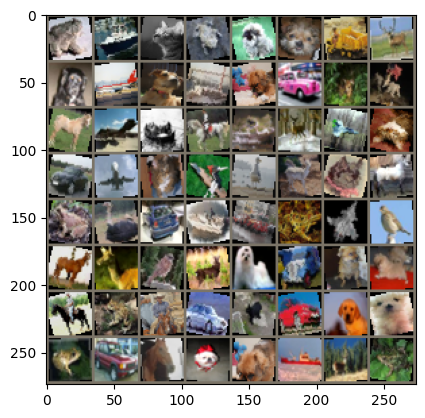

  frog   ship    cat   frog    dog    dog  truck   deer    dog  plane    dog   ship    dog    car   deer  horse  horse  plane   ship  horse   frog   deer  plane    cat    car  plane    cat   bird   bird   deer    cat  horse   frog   bird    car   ship  truck   frog  plane   bird  horse   deer   bird   deer    dog  truck    dog    dog  horse   frog  horse    car    cat    car    dog    dog   frog    car  horse    dog    dog   ship   deer   frog 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# function to show an image
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)


def imshow(img):
  img=img*std+mean #unnormalize
  npimg=img.numpy()   # converts pytorch tensor -> numpy , required becuase matplot works with numpy
  plt.imshow(np.transpose(npimg,(1,2,0)))  # rearrange the dimension from pytorch image format(C,H,W) to matplot expected format (H,W,C)
  plt.show()

#get random training image
dataiter=iter(trainloader)  # creates an iterator over the data loader
images,labels =next(dataiter)

#show image
imshow(torchvision.utils.make_grid(images))  # takes multiple images and puts them into a grid

#print labels
print(''.join(' %5s ' % classes[ labels[j] ] for j in range(batch_size)))






In [ ]:
# Lets build our Nueral Network and CNN for image classification
import torch
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


             nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64x8x8

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 128x4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10),
        )

    # ✅ SAME LEVEL as __init__
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [ ]:
# device set up
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#training our model
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()   # counts the correct predictions


    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / len(loader.dataset)

    return avg_loss, accuracy

In [ ]:
# Now we will evaluate our model
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    all_preds=[]
    all_labels=[]

    with torch.no_grad():   # IMPORTANT
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

            preds=outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / len(loader.dataset)

    return avg_loss, accuracy,all_preds,all_labels




In [ ]:
# Run your model
for epoch in range(1,6):
  train_loss,train_acc=train(model,trainloader,criterion,optimizer,device)
  test_loss,test_acc,all_preds,all_labels=evaluate(model,testloader,criterion,device)
  print(f"Epoch {epoch} | Train {train_acc:.1f}% | Test {test_acc:.1f}%")

Epoch 1 | Train 45.4% | Test 61.1%
Epoch 2 | Train 59.4% | Test 69.1%
Epoch 3 | Train 65.1% | Test 70.8%
Epoch 4 | Train 68.7% | Test 74.1%
Epoch 5 | Train 71.0% | Test 77.0%


              precision    recall  f1-score   support

           0       0.74      0.81      0.78      1000
           1       0.92      0.88      0.90      1000
           2       0.66      0.68      0.67      1000
           3       0.56      0.64      0.60      1000
           4       0.74      0.76      0.75      1000
           5       0.67      0.67      0.67      1000
           6       0.91      0.74      0.81      1000
           7       0.80      0.81      0.81      1000
           8       0.88      0.85      0.87      1000
           9       0.89      0.86      0.87      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



<Axes: >

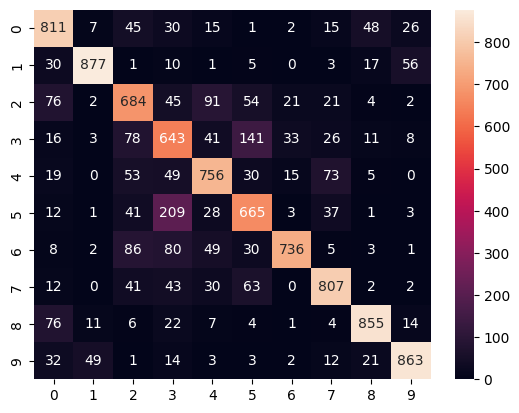

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d')